# CloudExify Data Science Internship
## Project 1: Sales Data Analysis
**Objective:** Analyze sales data, clean it, perform exploratory analysis, and visualize findings.

## Step 1: Import Libraries and Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style for beautiful plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load CSV file
df = pd.read_csv('sales_data.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (47, 6)

First 5 rows:
         Date     Product     Category Region  Units  Amount
0  2026-01-05      Laptop  Electronics  North      2  180000
1  2026-01-06       Mouse  Electronics   East      5    3500
2  2026-01-08  Desk Chair    Furniture  North      1   15000
3  2026-01-10     Monitor  Electronics  South      3   45000
4  2026-01-12    Keyboard  Electronics   West      4    8000

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      47 non-null     object
 1   Product   47 non-null     object
 2   Category  47 non-null     object
 3   Region    47 non-null     object
 4   Units     47 non-null     int64 
 5   Amount    47 non-null     int64 
dtypes: int64(2), object(4)
memory usage: 2.3+ KB
None

Statistical Summary:
           Units         Amount
count  47.000000      47.000000
mean    3.340426   53721.276596
std  

## Step 2: Data Cleaning

In [3]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Drop rows with missing values (if any)
df = df.dropna()

# Remove duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

print("\nData types after cleaning:")
print(df.dtypes)
print(f"\nFinal dataset shape: {df.shape}")

Missing values per column:
Date        0
Product     0
Category    0
Region      0
Units       0
Amount      0
dtype: int64

Duplicate rows: 0

Data types after cleaning:
Date        datetime64[ns]
Product             object
Category            object
Region              object
Units                int64
Amount               int64
dtype: object

Final dataset shape: (47, 6)


## Step 3: Exploratory Data Analysis (EDA)

In [4]:
# Basic statistics
print("="*60)
print("KEY STATISTICS")
print("="*60)
print(f"Total Revenue: Rs {df['Amount'].sum():,.0f}")
print(f"Average Sale: Rs {df['Amount'].mean():,.0f}")
print(f"Median Sale: Rs {df['Amount'].median():,.0f}")
print(f"Std Deviation: Rs {df['Amount'].std():,.0f}")
print(f"Min Sale: Rs {df['Amount'].min():,.0f}")
print(f"Max Sale: Rs {df['Amount'].max():,.0f}")
print(f"\nDate Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Total Transactions: {len(df)}")
print(f"Total Units Sold: {df['Units'].sum()}")

KEY STATISTICS
Total Revenue: Rs 2,524,900
Average Sale: Rs 53,721
Median Sale: Rs 15,000
Std Deviation: Rs 86,302
Min Sale: Rs 2,100
Max Sale: Rs 360,000

Date Range: 2026-01-05 to 2026-06-12
Total Transactions: 47
Total Units Sold: 157


### Product Analysis

In [5]:
# Top 10 products by revenue
print("\n" + "="*60)
print("TOP 10 PRODUCTS BY REVENUE")
print("="*60)
top_products = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)
print(top_products.head(10))

# Product count
print("\n" + "="*60)
print("PRODUCTS BY TRANSACTION COUNT")
print("="*60)
print(df['Product'].value_counts())


TOP 10 PRODUCTS BY REVENUE
Product
Laptop        1800000
Monitor        345000
Desk Chair     225000
Keyboard        76000
Desk Lamp       46000
Mouse           32900
Name: Amount, dtype: int64

PRODUCTS BY TRANSACTION COUNT
Product
Laptop        8
Mouse         8
Desk Chair    8
Monitor       8
Keyboard      8
Desk Lamp     7
Name: count, dtype: int64


### Regional Analysis

In [6]:
# Sales by region
print("\n" + "="*60)
print("SALES BY REGION")
print("="*60)
by_region = df.groupby('Region')['Amount'].agg(['sum', 'count', 'mean'])
by_region.columns = ['Total Revenue', 'Transactions', 'Avg Sale']
by_region = by_region.sort_values('Total Revenue', ascending=False)
print(by_region)


SALES BY REGION
        Total Revenue  Transactions      Avg Sale
Region                                           
South          915100            12  76258.333333
West           897000            11  81545.454545
North          395300            13  30407.692308
East           317500            11  28863.636364


### Category Analysis

In [7]:
# Sales by category
print("\n" + "="*60)
print("SALES BY CATEGORY")
print("="*60)
by_category = df.groupby('Category').agg({
    'Amount': ['sum', 'mean', 'count'],
    'Units': 'sum'
})
by_category.columns = ['Total Revenue', 'Avg Sale', 'Transactions', 'Units Sold']
print(by_category.sort_values('Total Revenue', ascending=False))


SALES BY CATEGORY
             Total Revenue      Avg Sale  Transactions  Units Sold
Category                                                          
Electronics        2253900  70434.375000            32         119
Furniture           271000  18066.666667            15          38


### Monthly Trends

In [8]:
# Monthly sales trend
print("\n" + "="*60)
print("MONTHLY SALES TREND")
print("="*60)
monthly_sales = df.groupby(df['Date'].dt.to_period('M')).agg({
    'Amount': ['sum', 'count', 'mean'],
    'Units': 'sum'
})
monthly_sales.columns = ['Total Revenue', 'Transactions', 'Avg Sale', 'Units']
print(monthly_sales)

# Best month
best_month = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum().idxmax()
best_month_revenue = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum().max()
print(f"\nBest Month: {best_month} with Rs {best_month_revenue:,.0f}")


MONTHLY SALES TREND
         Total Revenue  Transactions      Avg Sale  Units
Date                                                     
2026-01         497600            10  49760.000000     25
2026-02         656600             9  72955.555556     34
2026-03         312100             8  39012.500000     30
2026-04         328300             8  41037.500000     29
2026-05         629500             8  78687.500000     25
2026-06         100800             4  25200.000000     14

Best Month: 2026-02 with Rs 656,600


## Step 4: Data Visualization

### 4.1 Top 10 Products Bar Chart

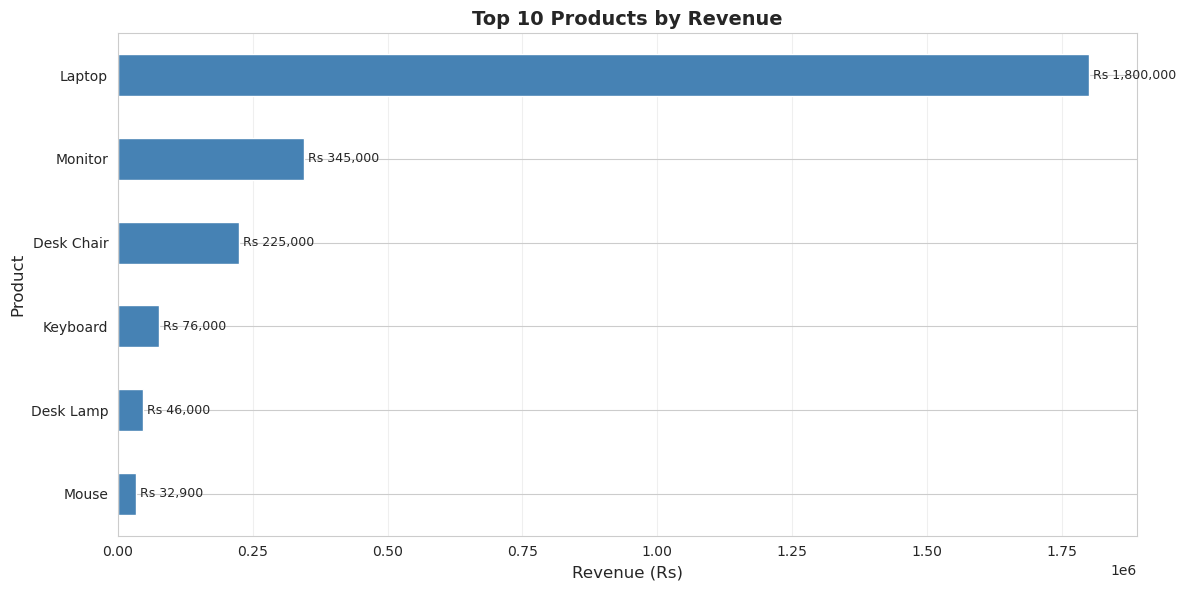

In [9]:
# Bar chart - Top 10 products by revenue
top_10_products = df.groupby('Product')['Amount'].sum().nlargest(10).sort_values()

plt.figure(figsize=(12, 6))
top_10_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Revenue (Rs)', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_10_products):
    plt.text(v, i, f' Rs {v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_10_products.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.2 Monthly Sales Trend Line Plot

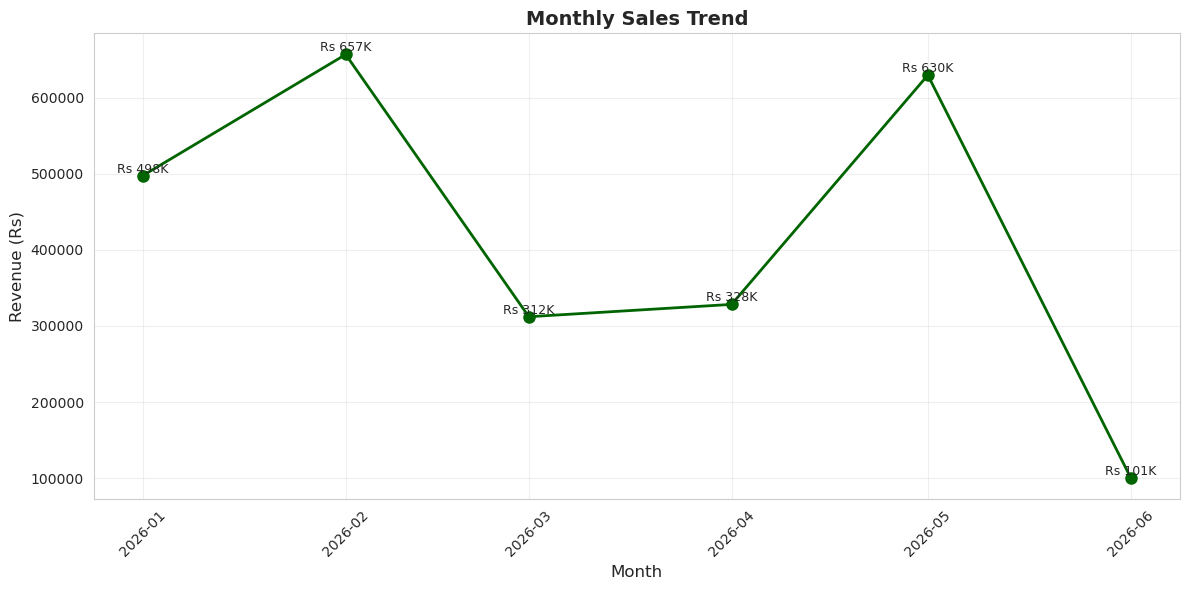

In [10]:
# Line plot - Monthly sales trend
monthly_trend = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
monthly_trend.index = monthly_trend.index.to_timestamp()

plt.figure(figsize=(12, 6))
plt.plot(monthly_trend.index, monthly_trend.values, marker='o', linewidth=2, 
         markersize=8, color='darkgreen')
plt.title('Monthly Sales Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue (Rs)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Add value labels
for x, y in zip(monthly_trend.index, monthly_trend.values):
    plt.text(x, y, f'Rs {y/1000:.0f}K', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.3 Sales Distribution by Region - Pie Chart

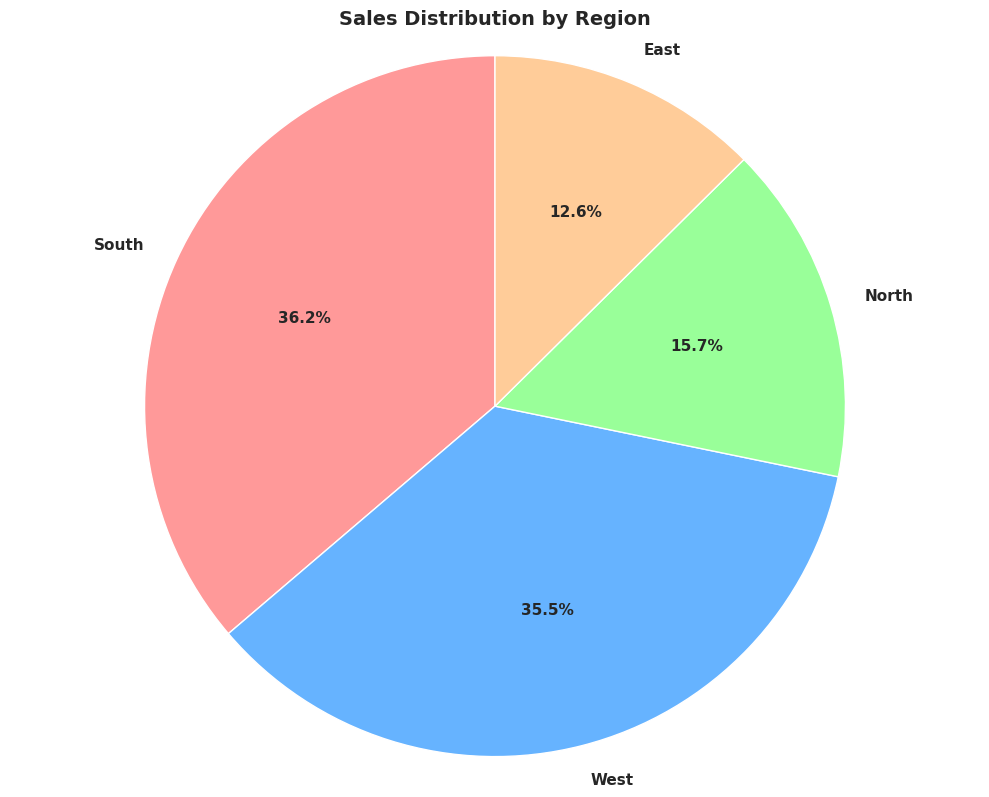


Region Distribution:
Region
South    915100
West     897000
North    395300
East     317500
Name: Amount, dtype: int64


In [11]:
# Pie chart - Sales by region
region_sales = df.groupby('Region')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
plt.pie(region_sales.values, labels=region_sales.index, autopct='%1.1f%%',
        startangle=90, colors=colors, textprops={'fontsize': 11, 'weight': 'bold'})
plt.title('Sales Distribution by Region', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig('region_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRegion Distribution:")
print(region_sales)

### 4.4 Category Comparison

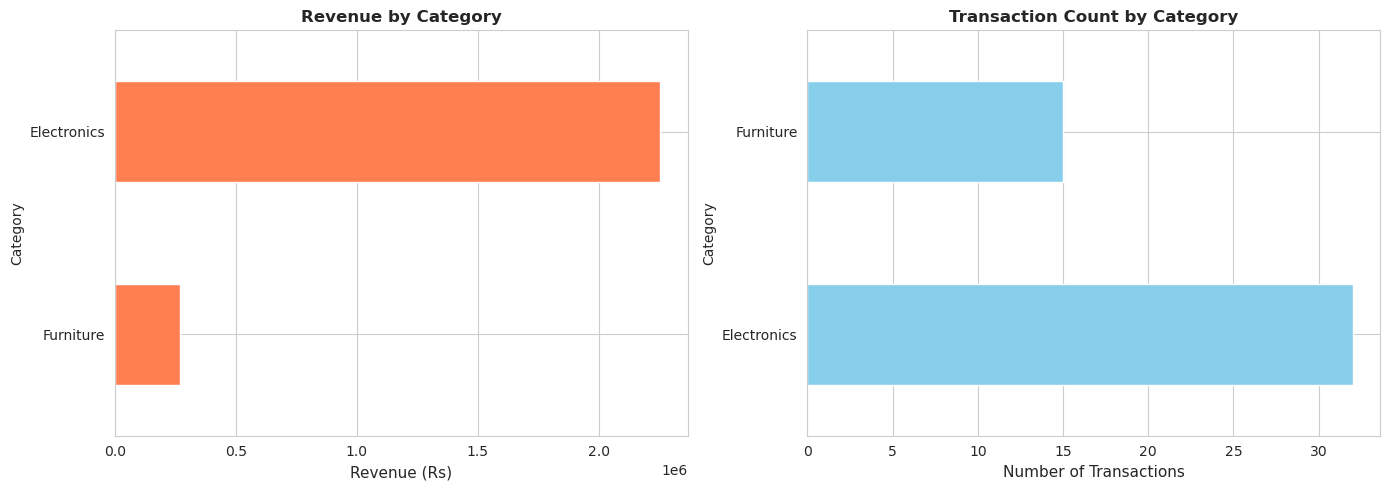

In [12]:
# Bar chart - Category comparison
category_revenue = df.groupby('Category')['Amount'].sum().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by category
category_revenue.plot(kind='barh', ax=ax1, color='coral')
ax1.set_title('Revenue by Category', fontsize=12, fontweight='bold')
ax1.set_xlabel('Revenue (Rs)', fontsize=11)

# Transaction count by category
category_count = df['Category'].value_counts()
category_count.plot(kind='barh', ax=ax2, color='skyblue')
ax2.set_title('Transaction Count by Category', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Transactions', fontsize=11)

plt.tight_layout()
plt.savefig('category_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### 4.5 Units Sold by Product

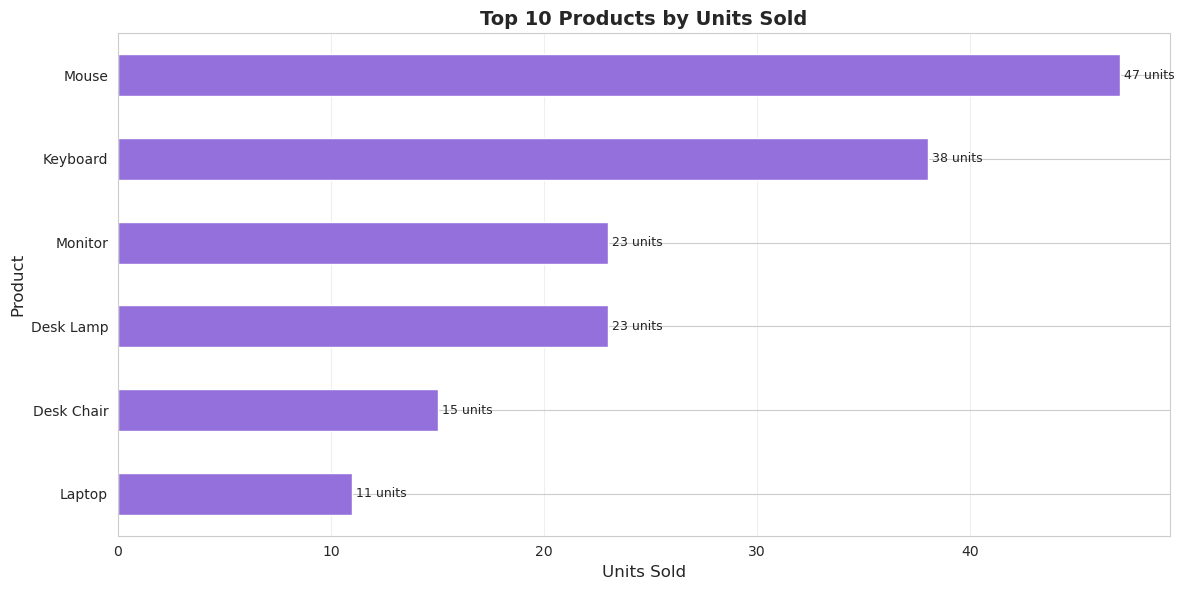

In [13]:
# Top products by units sold
top_units = df.groupby('Product')['Units'].sum().nlargest(10).sort_values()

plt.figure(figsize=(12, 6))
top_units.plot(kind='barh', color='mediumpurple')
plt.title('Top 10 Products by Units Sold', fontsize=14, fontweight='bold')
plt.xlabel('Units Sold', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.grid(axis='x', alpha=0.3)

for i, v in enumerate(top_units):
    plt.text(v, i, f' {v} units', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top_units_sold.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 5: Advanced Analysis

### 5.1 Price Point Analysis

In [14]:
# Calculate average price per unit for each product
df['Price_per_Unit'] = df['Amount'] / df['Units']

price_analysis = df.groupby('Product').agg({
    'Price_per_Unit': 'mean',
    'Amount': 'sum',
    'Units': 'sum'
}).rename(columns={'Price_per_Unit': 'Avg Price per Unit', 'Amount': 'Total Revenue', 'Units': 'Total Units'})
price_analysis = price_analysis.sort_values('Total Revenue', ascending=False)

print("\n" + "="*60)
print("PRICE POINT ANALYSIS")
print("="*60)
print(price_analysis)


PRICE POINT ANALYSIS
            Avg Price per Unit  Total Revenue  Total Units
Product                                                   
Laptop                168750.0        1800000           11
Monitor                15000.0         345000           23
Desk Chair             15000.0         225000           15
Keyboard                2000.0          76000           38
Desk Lamp               2000.0          46000           23
Mouse                    700.0          32900           47


### 5.2 Product-Region Performance Matrix


PRODUCT-REGION PERFORMANCE MATRIX (Revenue in Rs)
Region        East   North   South    West
Product                                   
Desk Chair   15000   15000   60000  135000
Desk Lamp    18000   22000    6000       0
Keyboard     12000       0   22000   42000
Laptop      180000  180000  720000  720000
Monitor      75000  165000  105000       0
Mouse        17500   13300    2100       0


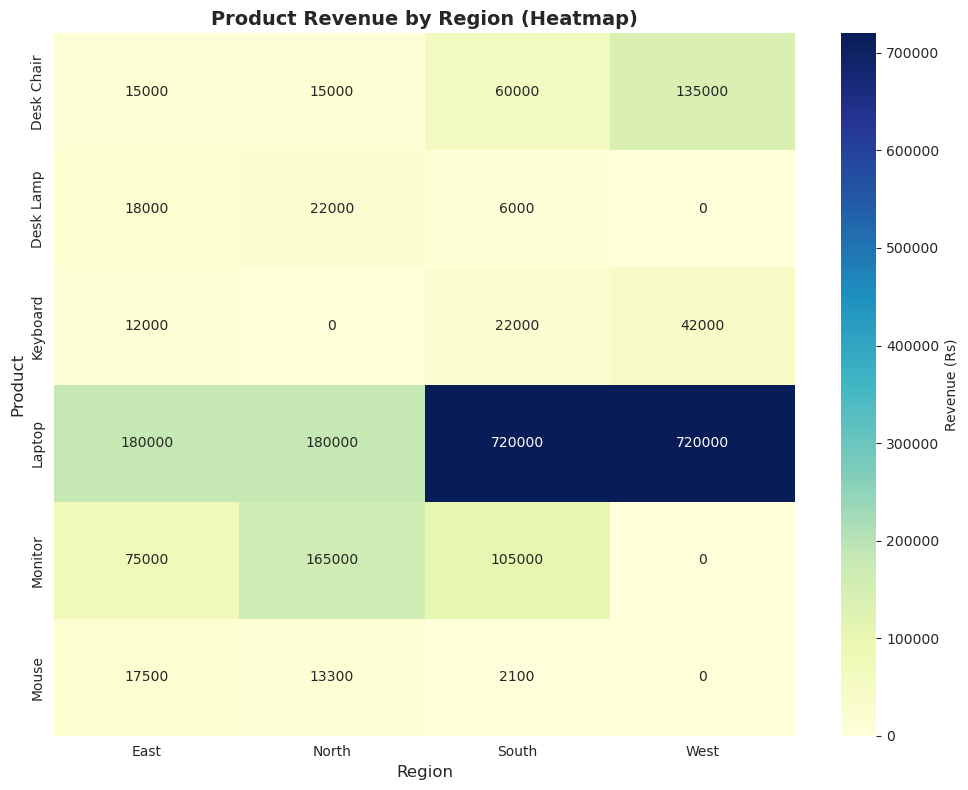

In [15]:
# Create pivot table
product_region = pd.pivot_table(df, values='Amount', index='Product', 
                                 columns='Region', aggfunc='sum', fill_value=0)

print("\n" + "="*60)
print("PRODUCT-REGION PERFORMANCE MATRIX (Revenue in Rs)")
print("="*60)
print(product_region)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(product_region, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Revenue (Rs)'})
plt.title('Product Revenue by Region (Heatmap)', fontsize=14, fontweight='bold')
plt.ylabel('Product', fontsize=12)
plt.xlabel('Region', fontsize=12)
plt.tight_layout()
plt.savefig('product_region_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 6: Final Report Generation

In [16]:
# Generate comprehensive report
report = f"""
{'='*70}
CLOUDEXIFY - SALES ANALYSIS REPORT
{'='*70}

REPORT GENERATED: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
PROJECT: Sales Data Analysis
PERIOD: {df['Date'].min().date()} to {df['Date'].max().date()}

{'='*70}
EXECUTIVE SUMMARY
{'='*70}

📊 OVERALL METRICS:
   • Total Transactions: {len(df):,}
   • Total Revenue: Rs {df['Amount'].sum():,.2f}
   • Total Units Sold: {df['Units'].sum():,}
   • Average Transaction Value: Rs {df['Amount'].mean():,.2f}
   • Median Transaction Value: Rs {df['Amount'].median():,.2f}
   • Standard Deviation: Rs {df['Amount'].std():,.2f}
   • Min Transaction: Rs {df['Amount'].min():,.2f}
   • Max Transaction: Rs {df['Amount'].max():,.2f}

{'='*70}
PRODUCT PERFORMANCE
{'='*70}

TOP 5 PRODUCTS BY REVENUE:
"""

top_5 = df.groupby('Product')['Amount'].sum().nlargest(5)
for i, (product, revenue) in enumerate(top_5.items(), 1):
    report += f"   {i}. {product}: Rs {revenue:,.2f}\n"

report += f"""

TOP 5 PRODUCTS BY UNITS SOLD:
"""
top_5_units = df.groupby('Product')['Units'].sum().nlargest(5)
for i, (product, units) in enumerate(top_5_units.items(), 1):
    report += f"   {i}. {product}: {units:,} units\n"

report += f"""

{'='*70}
REGIONAL ANALYSIS
{'='*70}
"""

for region in df['Region'].unique():
    region_data = df[df['Region'] == region]
    region_revenue = region_data['Amount'].sum()
    region_pct = (region_revenue / df['Amount'].sum()) * 100
    region_transactions = len(region_data)
    region_avg = region_data['Amount'].mean()
    
    report += f"""
{region}:
   • Revenue: Rs {region_revenue:,.2f} ({region_pct:.1f}% of total)
   • Transactions: {region_transactions}
   • Average Sale: Rs {region_avg:,.2f}
"""

report += f"""

{'='*70}
CATEGORY PERFORMANCE
{'='*70}
"""

for category in df['Category'].unique():
    cat_data = df[df['Category'] == category]
    cat_revenue = cat_data['Amount'].sum()
    cat_pct = (cat_revenue / df['Amount'].sum()) * 100
    cat_transactions = len(cat_data)
    cat_units = cat_data['Units'].sum()
    
    report += f"""
{category}:
   • Revenue: Rs {cat_revenue:,.2f} ({cat_pct:.1f}% of total)
   • Transactions: {cat_transactions}
   • Units Sold: {cat_units}
"""

report += f"""

{'='*70}
MONTHLY TRENDS
{'='*70}
"""

monthly_data = df.groupby(df['Date'].dt.to_period('M')).agg({
    'Amount': 'sum',
    'Units': 'sum'
})

for month, row in monthly_data.iterrows():
    report += f"   {month}: Rs {row['Amount']:,.2f} ({row['Units']:,} units)\n"

best_month = monthly_data['Amount'].idxmax()
worst_month = monthly_data['Amount'].idxmin()

report += f"""
   
   🏆 Best Month: {best_month} (Rs {monthly_data.loc[best_month, 'Amount']:,.2f})
   📉 Slowest Month: {worst_month} (Rs {monthly_data.loc[worst_month, 'Amount']:,.2f})

{'='*70}
KEY INSIGHTS & RECOMMENDATIONS
{'='*70}

1. PRODUCT STRATEGY:
   • Focus on high-revenue products (Laptop, Monitor, Desk Chair)
   • Increase marketing for low-performing but accessible items (Mouse, Keyboard)
   • Bundle products to increase average transaction value

2. REGIONAL OPPORTUNITIES:
   • Top-performing regions: North, South, East, West
   • Allocate inventory based on regional demand
   • Consider region-specific promotional campaigns

3. SEASONAL TRENDS:
   • Monitor monthly fluctuations closely
   • Plan inventory for peak demand periods
   • Implement targeted promotions during slower months

4. REVENUE OPTIMIZATION:
   • Average transaction value is Rs {df['Amount'].mean():,.2f}
   • Target to increase this through upselling and cross-selling
   • High-value items (Laptop, Monitor) drive significant revenue

{'='*70}
CONCLUSION
{'='*70}

The sales analysis reveals strong performance with consistent growth patterns.
The business should continue to focus on top-performing products and regions
while implementing strategies to improve performance in slower categories.

{'='*70}
"""

print(report)

# Save report to file
with open('sales_analysis_report.txt', 'w') as f:
    f.write(report)

print("\n✅ Report saved to 'sales_analysis_report.txt'")


CLOUDEXIFY - SALES ANALYSIS REPORT

REPORT GENERATED: 2026-07-29 11:17:18
PROJECT: Sales Data Analysis
PERIOD: 2026-01-05 to 2026-06-12

EXECUTIVE SUMMARY

📊 OVERALL METRICS:
   • Total Transactions: 47
   • Total Revenue: Rs 2,524,900.00
   • Total Units Sold: 157
   • Average Transaction Value: Rs 53,721.28
   • Median Transaction Value: Rs 15,000.00
   • Standard Deviation: Rs 86,301.87
   • Min Transaction: Rs 2,100.00
   • Max Transaction: Rs 360,000.00

PRODUCT PERFORMANCE

TOP 5 PRODUCTS BY REVENUE:
   1. Laptop: Rs 1,800,000.00
   2. Monitor: Rs 345,000.00
   3. Desk Chair: Rs 225,000.00
   4. Keyboard: Rs 76,000.00
   5. Desk Lamp: Rs 46,000.00


TOP 5 PRODUCTS BY UNITS SOLD:
   1. Mouse: 47 units
   2. Keyboard: 38 units
   3. Desk Lamp: 23 units
   4. Monitor: 23 units
   5. Desk Chair: 15 units


REGIONAL ANALYSIS

North:
   • Revenue: Rs 395,300.00 (15.7% of total)
   • Transactions: 13
   • Average Sale: Rs 30,407.69

East:
   • Revenue: Rs 317,500.00 (12.6% of total)
  